# Grid-based simulation

Prior to implementing the model with ELFI, a grid-based simulation was used to explore the identifiability of the parameters and what summary statistics to choose. 

This notebook contains an example of grid-based simulation.

In [12]:
import numpy as np
import importlib

from grid_params import * # import parameters for the grid simulation
from cluster.scripts.load_data import *

import cluster.scripts.BSI_functions
importlib.reload(cluster.scripts.BSI_functions) # for changes to take effect
from cluster.scripts.BSI_functions import *

import cluster.scripts.SIR_functions
importlib.reload(cluster.scripts.SIR_functions) # for changes to take effect
from cluster.scripts.SIR_functions import *



n_years = 14
bsi_obs = get_incidence_data("data/NORM_incidence.csv", clade = clade, is_prop = is_prop, n_incidence_pop = pop_size)

Loading BSI_functions.py


In [14]:
par1_range = [0, 1]
par2_range = [0, 0.1]
p1 = par1_range[0]
p2 = par2_range[0]

p1_step = (par1_range[1] - par1_range[0])/n_grid
p2_step = (par2_range[1] - par2_range[0])/n_grid

n_grid = 1000

for i in range(0, n_grid):
    
    
    p1 += p1_step
    p2 += p2_step

In [15]:
# Creating an evenly-spaced grid for parameters beta and gamma
# Note: by using an evenly-spaced grid, we allow for parameter combinations that are not feasible:
# values of R0 less than 1 or SIR curves that could be negative.

par1_range = [0, 1] # beta
par2_range = [0, 0.1] # gamma
n_grid = 100 # Results in n_grid*n_grid parameter pairs
p1_step = (par1_range[1] - par1_range[0])/n_grid
p2_step = (par2_range[1] - par2_range[0])/n_grid

S1_obs = np.log(np.max(bsi_obs) + 1)
S2_obs = np.log(np.argmax(bsi_obs) + 1)
S1_mat = np.zeros((n_grid, n_grid))
S2_mat = np.zeros((n_grid, n_grid))
dist_mat = np.zeros((n_grid, n_grid))

grid_I = np.zeros((n_grid, n_grid, n_weeks))
grid_conv_BSI = np.zeros((n_grid, n_grid, n_years))
p1 = par1_range[0]
p2 = par2_range[0]

p1s = np.zeros(n_grid*n_grid)
p2s = np.zeros(n_grid*n_grid)
p = 0 # number of parameter pairs, used to indexing p1s and p2s

for i in range(0, n_grid): # par1
    p2 = par2_range[0]
    for j in range(0, n_grid): # par2
        # Calculate the SIR simulation with this pair of parameters.
        # Save the I compartment, corresponding to colonisation
        
        
        SISsim = SIS(p1, p2, nt = n_weeks, N = pop_size, I0 = None, reparam = reparam, is_prop = is_prop)
        OR_hat = get_OR_hat_pars(or_data, clade = clade, dataset = obs_data) # returns mean and CIs for OR
        weekly_BSI = col_to_BSI(SISsim, OR_hat[0], theta_c = theta_c, theta_bsi = theta_bsi, is_prop = is_prop)
        yearly_BSI = sum_over_bsi(weekly_BSI, time_period = time_period)
        conv_BSI = exp_smoother(yearly_BSI, alpha = alpha)

        S1_mat[i,j] = np.log(np.max(conv_BSI[0]) + 1)
        S2_mat[i,j] = np.log(np.argmax(conv_BSI[0]) + 1)
        dist_mat[i,j] = (S1_mat[i,j] - S1_obs)**2 + (S2_mat[i,j] - S2_obs)**2
        #grid_I[i,j] = ...
      
        for k in range(0, n_years):
            grid_I[i,j,k] = SISsim[1][0][k]
            grid_conv_BSI[i,j,k] = conv_BSI[0][k] # calculate corresponding BSI
        
        # add new grids for other steps of interest
        
        # save the parameter pair
        p1s[p] = p1
        p2s[p] = p2
        
        if p%1000 == 0:
            print(f"Parameter pair n: {p}/{n_grid*n_grid}")
            
        p2 += p2_step
        p += 1 # number of parameter pairs
        
    p1 += p1_step

Parameter pair n: 0/10000
Parameter pair n: 1000/10000
Parameter pair n: 2000/10000
Parameter pair n: 3000/10000
Parameter pair n: 4000/10000
Parameter pair n: 5000/10000
Parameter pair n: 6000/10000
Parameter pair n: 7000/10000
Parameter pair n: 8000/10000
Parameter pair n: 9000/10000


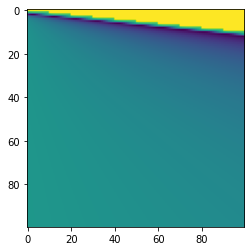

In [16]:
# Visualization of the distance as a heatmap:


fig, ax = plt.subplots()
im = ax.imshow(dist_mat)
plt.show()


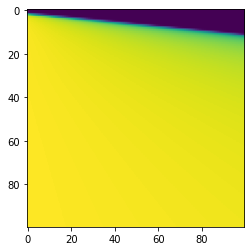

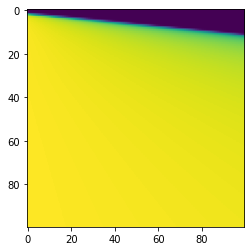

In [17]:
fig, ax = plt.subplots()
im = ax.imshow(S1_mat)
plt.show()

fig, ax = plt.subplots()
im = ax.imshow(S1_mat)
plt.show()

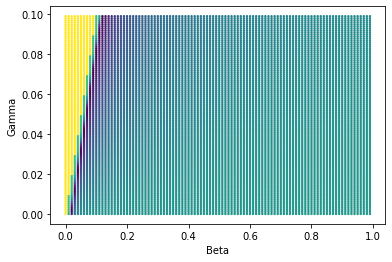

In [18]:
# Parameters vs distance:
plt.scatter(p1s, p2s, s = 2, c = dist_mat)
plt.xlabel("Beta")
plt.ylabel("Gamma")
plt.show()

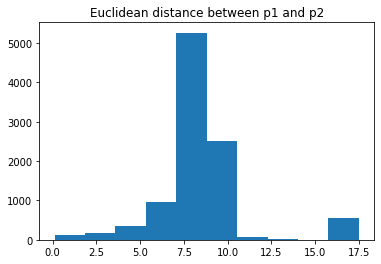

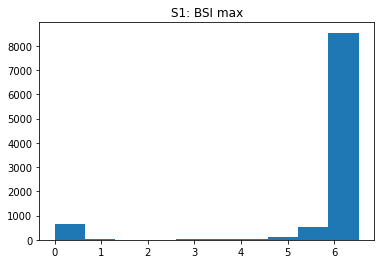

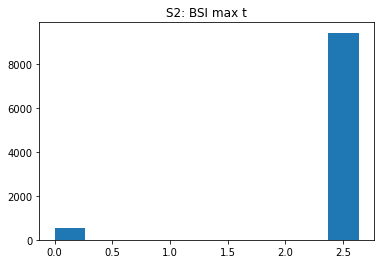

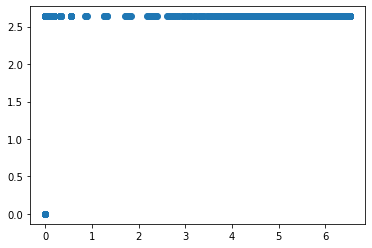

In [19]:
# Histogram of distances:

plt.hist(dist_mat.flatten())
plt.title("Euclidean distance between p1 and p2")
plt.show()


# Histogram of S1:
plt.hist(S1_mat.flatten()) # most of the prior parameter pairs produce LOG(a max number of BSI cases of 5-6 + 1) NOTE THE LOG!
plt.title("S1: BSI max")
plt.show()

# Histogram of S2:
plt.hist(S2_mat.flatten()) # Most of the prior parameters in the grid produce BSI curves that produce their maximum values at zero. NOTE LOGARITHMIC!
plt.title("S2: BSI max t")
plt.show()

plt.scatter(S1_mat.flatten(), S2_mat.flatten()) # does this work and if so, what is the interpretation?
plt.show()

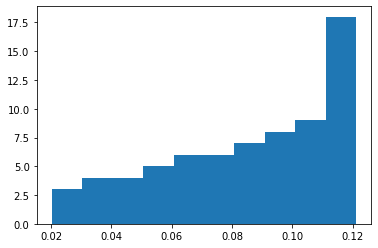

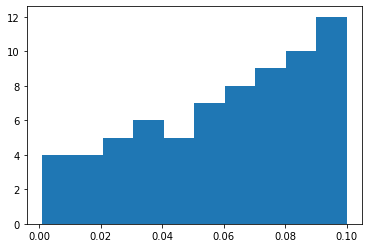

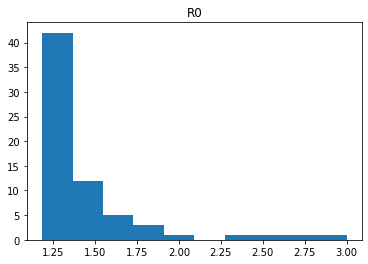

In [20]:
# Posterior histograms with a threshold parameter

eps = 1

p1s = np.linspace(par1_range[0], par1_range[1], n_grid)
p2s = np.linspace(par2_range[0], par2_range[1], n_grid)

plt.hist(p1s[np.where(dist_mat < eps)[0]]) 
plt.show()

plt.hist(p2s[np.where(dist_mat < eps)[1]]) # classic beta doesn't identify with the simple model :)
plt.show()

r0 = p1s[np.where(dist_mat < eps)[0]]/p2s[np.where(dist_mat < eps)[1]]
plt.hist(r0[np.where(r0 < 5)])
plt.title("R0")
plt.show()


## Clade A

## Clade C2